In [5]:
from sliced_hierarchical_OT import calc_HOT_between_subsets, calc_SHOT_between_subsets, compute_wasserstein_distance
import torch
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from perceptual_patch_utils import * 
from plotting_utils import plot_means_with_errorbars
from tqdm import tqdm

def calc_OT_between_subsets(dataset, dataset2, im_num=32):
    mu_im1 = dataset.images_torch.reshape(im_num, -1)
    mu_im2 = dataset2.images_torch.reshape(im_num, -1)
    return compute_wasserstein_distance(mu_im1, mu_im2)
    
def create_overview_dict(itermax, param_ls):
    dict_overview = {"HOT": {}, "SHOT": {}, "OT": {}, "KID": {}}
    for param in param_ls:
        for key in dict_overview.keys():
            dict_overview[key][param] = []
            
    return dict_overview


def eval_overview_dict(dict_overview):
    hot_means = pd.DataFrame.from_dict(dict_overview["HOT"]).mean().values
    hot_stds = pd.DataFrame.from_dict(dict_overview["HOT"]).std().values
    shot_means = pd.DataFrame.from_dict(dict_overview["SHOT"]).mean().values
    shot_stds = pd.DataFrame.from_dict(dict_overview["SHOT"]).std().values
    ot_means = pd.DataFrame.from_dict(dict_overview["OT"]).mean().values
    ot_stds = pd.DataFrame.from_dict(dict_overview["OT"]).std().values
    kid_means = pd.DataFrame.from_dict(dict_overview["KID"]).mean().values
    kid_stds = pd.DataFrame.from_dict(dict_overview["KID"]).std().values
    return hot_means, hot_stds, shot_means, shot_stds, ot_means, ot_stds, kid_means, kid_stds

save_folder = "Perceptual_Viz/"

# Persistence

  0%|                                                                                                                                                                                                                                                   | 0/5 [00:00<?, ?it/s]

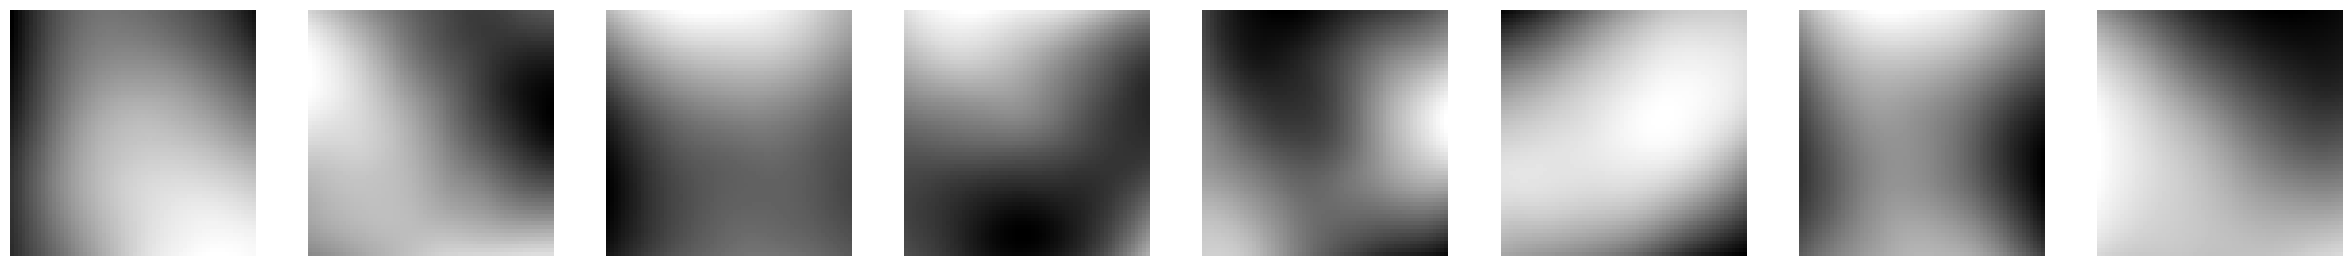

 20%|███████████████████████████████████████████████                                                                                                                                                                                            | 1/5 [00:43<02:53, 43.48s/it]

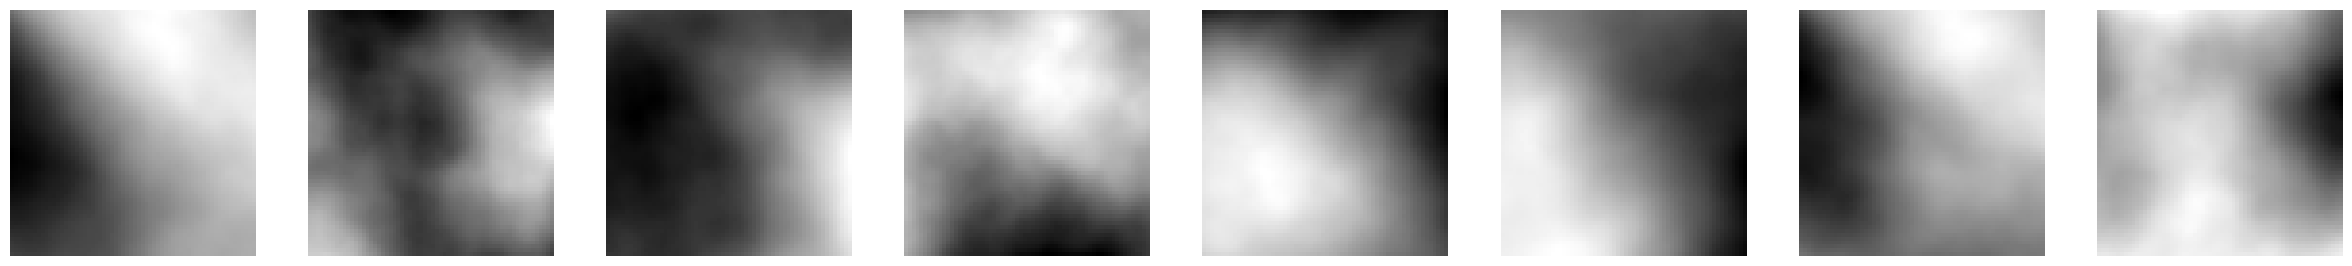

 40%|██████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                             | 2/5 [01:25<02:08, 42.78s/it]

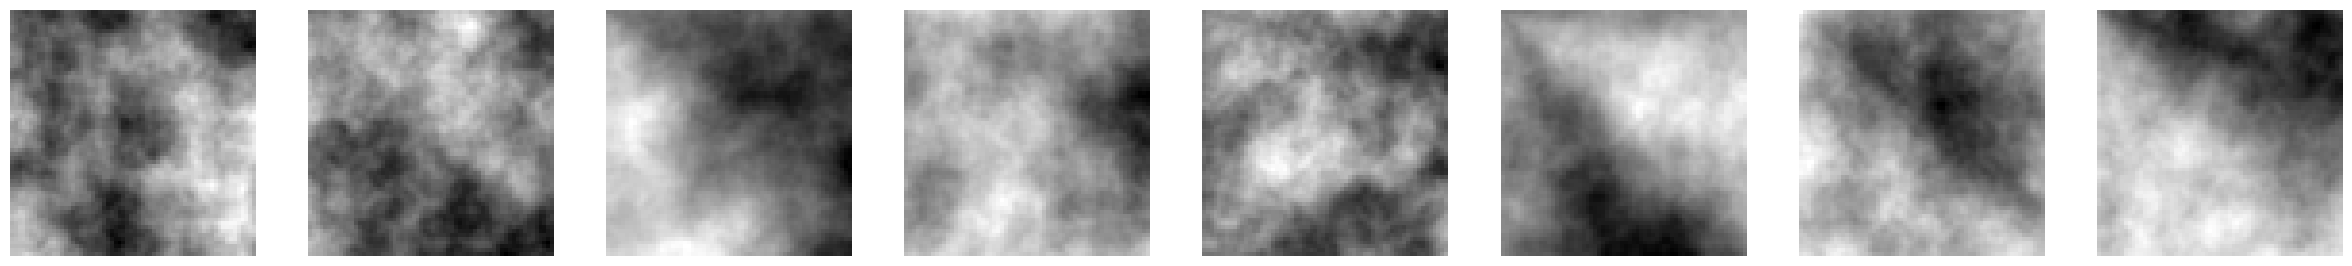

 60%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                              | 3/5 [02:07<01:25, 42.51s/it]

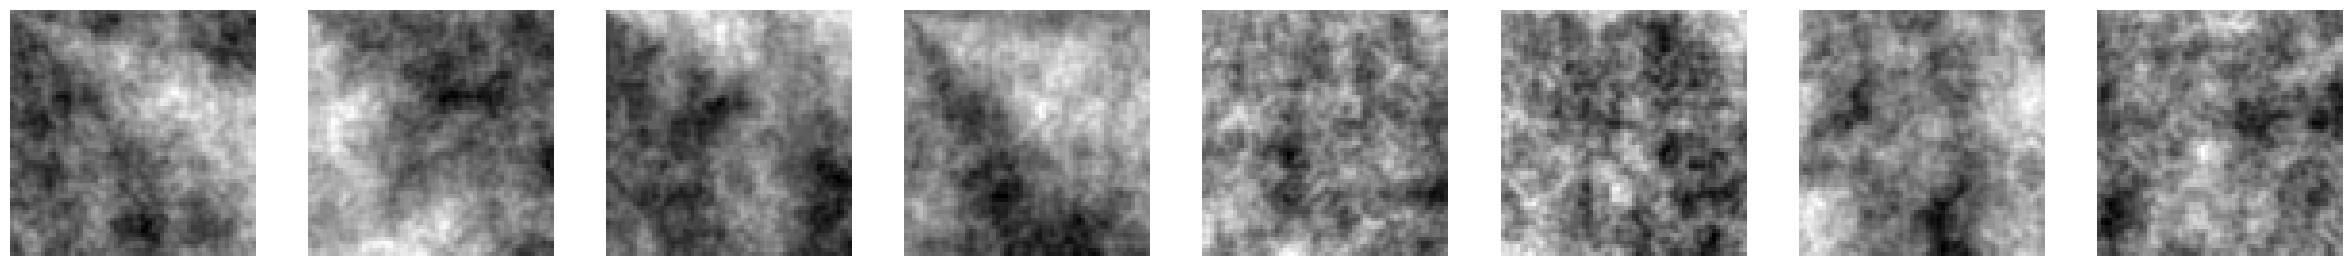

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                               | 4/5 [02:50<00:42, 42.52s/it]

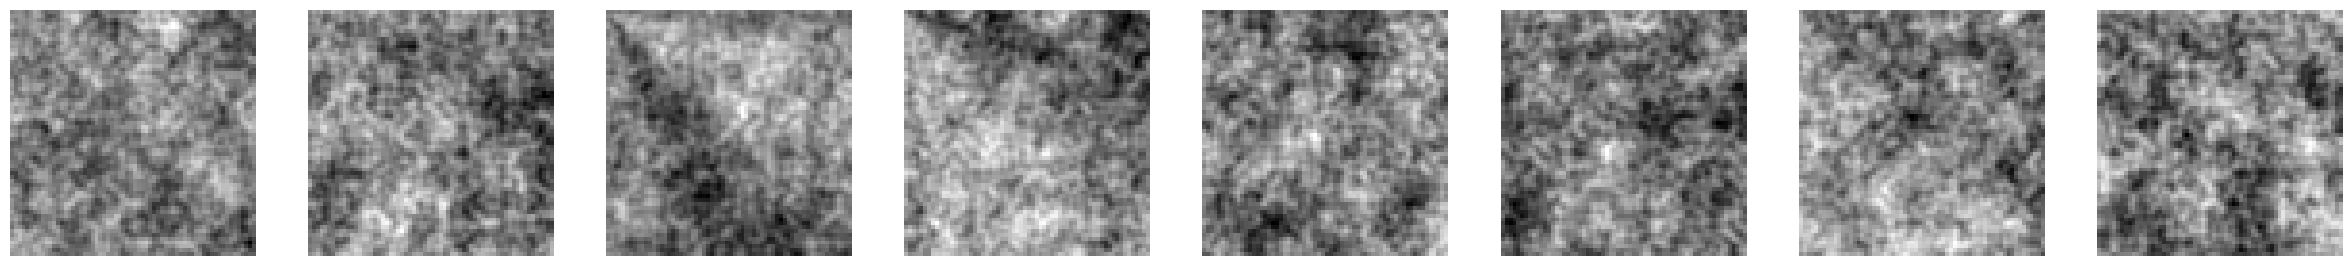

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [03:28<00:00, 41.77s/it]


In [6]:
np.random.seed(42)
torch.manual_seed(42)
persistence_ls = [0.1, 0.25, .5, .75, 1.]
itermax = 5
dict_overview_p = create_overview_dict(itermax, persistence_ls)

batch_size = 32
im_size = 64
patch_sz = 8
p_target = .5
device = "cuda"
constant_lac = 2.5
constant_oct = 5
x_min = 0. * np.min(persistence_ls)
if x_min <= 0:
    x_min = None 
for iternum in range(itermax):        
    dataset = PerlinPatches(patch_sz, batch_size, im_size, persistence=p_target, lacunarity=constant_lac, seed=iternum+100, device=device,
                           octaves=constant_oct)
    for p in tqdm(persistence_ls):
        dataset2 = PerlinPatches(patch_sz, batch_size, im_size, persistence=p, lacunarity=constant_lac, seed=iternum, device=device,
                                octaves=constant_oct)
        hot = calc_HOT_between_subsets(dataset, dataset2, dim=patch_sz**2).item()
        dict_overview_p["HOT"][p].append(hot)
        shot = calc_SHOT_between_subsets(dataset, dataset2, dim=patch_sz**2, 
                                         length_scale=.1, outer_pnum=100, grid_n=50, inner_pnum=100).item()
        dict_overview_p["SHOT"][p].append(shot)
        kid = calc_KID_between_subsets(dataset, dataset2).item()
        dict_overview_p["KID"][p].append(kid)
        ot = calc_OT_between_subsets(dataset, dataset2, im_num=batch_size).item()
        dict_overview_p["OT"][p].append(ot)

        if iternum == 0:
            savename = save_folder + f"p_texture/perlin_p={p}.png"
            dataset_viz = PerlinPatches(patch_sz, 8, im_size, persistence=p, lacunarity=constant_lac, seed=iternum, device=device,
                                       octaves=constant_oct)
            dataset_viz.__visualize__(savename=savename)


hot_means, hot_stds, shot_means, shot_stds, ot_means, ot_stds, kid_means, kid_stds = eval_overview_dict(dict_overview_p)

plot_means_with_errorbars(persistence_ls, hot_means, hot_stds, xlabel="Persistence in Target", 
                          ylabel="WoW", save_path=save_folder + "wow_p.png", x_target=p_target, x_min=x_min, legend=False, 
                          ystrnum=5)

plot_means_with_errorbars(persistence_ls, shot_means, shot_stds, xlabel="Persistence in Target", 
                          ylabel="Ours", save_path=save_folder + "swow_p.png", 
                          x_target=p_target, x_min=x_min, legend=False, ystrnum=5)


plot_means_with_errorbars(persistence_ls, ot_means, ot_stds, xlabel="Persistence in Target", 
                          ylabel="Wasserstein", save_path=save_folder + "ot_p.png", 
                          x_target=p_target, x_min=x_min, legend=False, ystrnum=5)

plot_means_with_errorbars(persistence_ls, kid_means, kid_stds, xlabel="Persistence in Target", 
                          ylabel="KID", save_path=save_folder + "kid_p.png", 
                          x_target=p_target, x_min=x_min, legend=False, ystrnum=5)



# Lacunarity

  0%|                                                                                                                                                                                                                                                   | 0/5 [00:00<?, ?it/s]

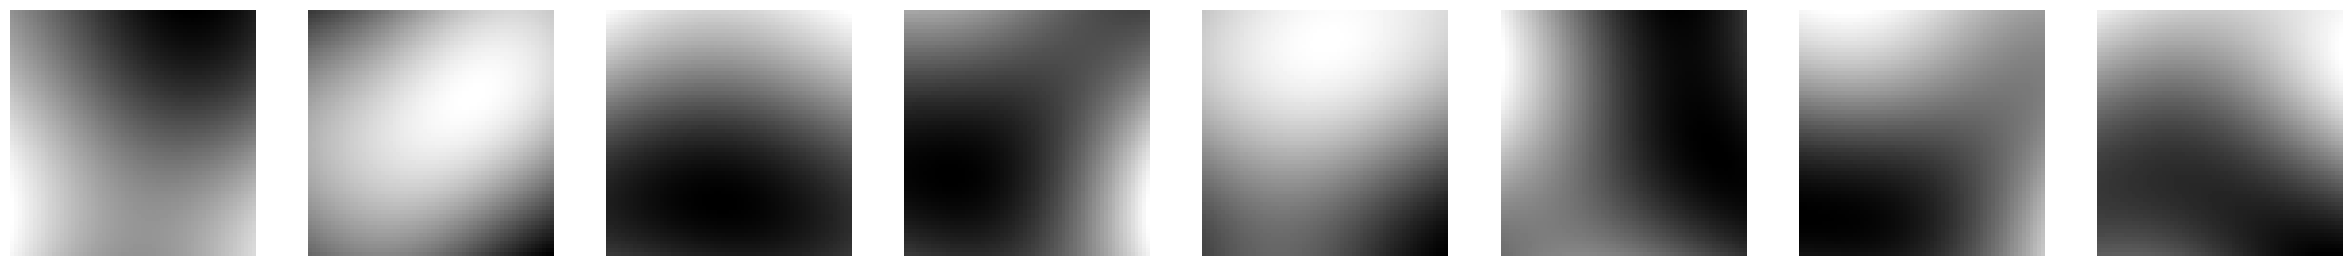

 20%|███████████████████████████████████████████████                                                                                                                                                                                            | 1/5 [00:42<02:49, 42.30s/it]

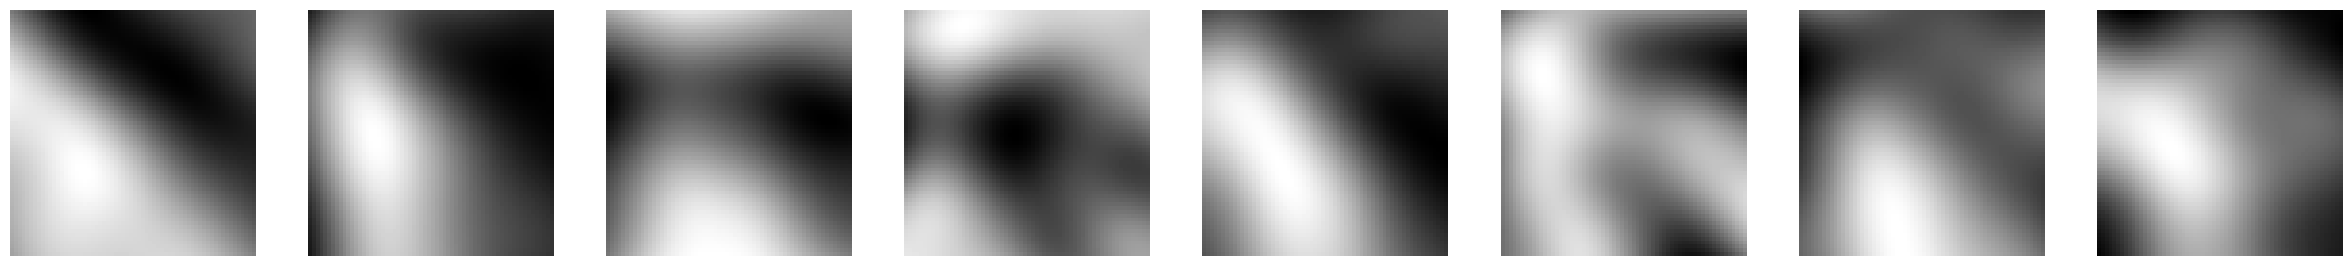

 40%|██████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                                             | 2/5 [01:25<02:08, 43.00s/it]

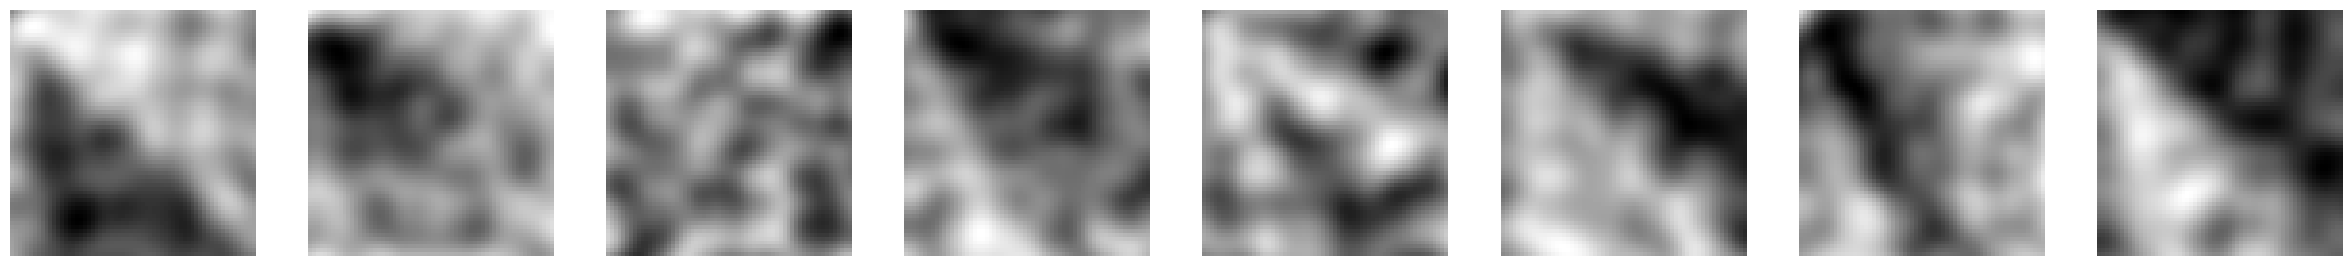

 60%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                              | 3/5 [02:09<01:26, 43.31s/it]

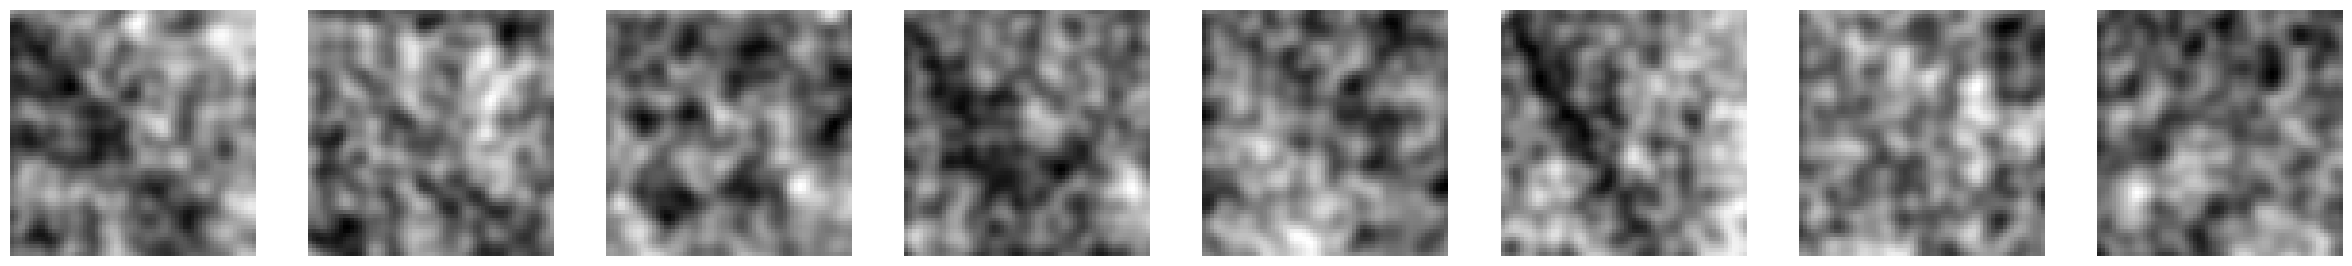

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                               | 4/5 [02:52<00:43, 43.22s/it]

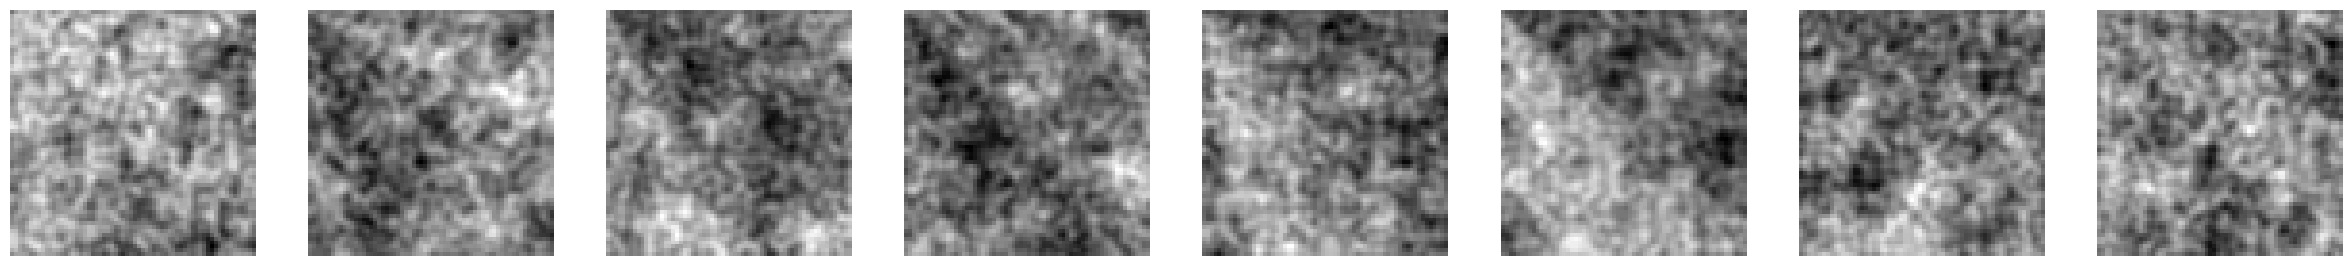

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [03:29<00:00, 41.87s/it]


In [7]:
np.random.seed(42)
torch.manual_seed(42)

lacunarity_ls = [1., 1.25, 1.5, 1.75, 2.]
itermax = 5
dict_overview_lac = create_overview_dict(itermax, lacunarity_ls)
device = "cuda"
batch_size = 32
im_size = 64 #128
patch_sz = 8
lac_target = 1.5
x_min =  0.9 * np.min(lacunarity_ls)
for iternum in range(itermax):        
    dataset = PerlinPatches(patch_sz, batch_size, im_size, persistence=1., lacunarity=lac_target, seed=iternum+100, device=device)
    for lac in tqdm(lacunarity_ls):
        dataset2 = PerlinPatches(patch_sz, batch_size, im_size, persistence=1., lacunarity=lac, seed=iternum, device=device)
        hot = calc_HOT_between_subsets(dataset, dataset2, dim=patch_sz**2).item()
        dict_overview_lac["HOT"][lac].append(hot)
        shot = calc_SHOT_between_subsets(dataset, dataset2, dim=patch_sz**2, 
                                         length_scale=.1, outer_pnum=100, grid_n=50, inner_pnum=100).item()
        dict_overview_lac["SHOT"][lac].append(shot)
        kid = calc_KID_between_subsets(dataset, dataset2).item()
        dict_overview_lac["KID"][lac].append(kid)
        ot = calc_OT_between_subsets(dataset, dataset2, im_num=batch_size).item()
        dict_overview_lac["OT"][lac].append(ot)
        if iternum == 0:
            savename = save_folder + f"lac_texture/perlin_lac={lac}.png"
            dataset_viz = PerlinPatches(patch_sz, 8, im_size, persistence=1., lacunarity=lac, seed=iternum, device=device)
            dataset_viz.__visualize__(savename=savename)


hot_means, hot_stds, shot_means, shot_stds, ot_means, ot_stds, kid_means, kid_stds = eval_overview_dict(dict_overview_lac)

plot_means_with_errorbars(lacunarity_ls, hot_means, hot_stds, xlabel="Lacunarity in Target", 
                          ylabel="WoW", save_path=save_folder + "wow_lac.png", x_target=lac_target, x_min=x_min, legend=False, 
                          ystrnum=5)

plot_means_with_errorbars(lacunarity_ls, shot_means, shot_stds, xlabel="Lacunarity in Target", 
                          ylabel="Ours", save_path=save_folder + "swow_lac.png", x_target=lac_target, x_min=x_min, legend=True, 
                          ystrnum=5)

plot_means_with_errorbars(lacunarity_ls, ot_means, ot_stds, xlabel="Lacunarity in Target", 
                          ylabel="Wasserstein", save_path=save_folder + "ot_lac.png", x_target=lac_target, x_min=x_min, legend=False, 
                          ystrnum=5)

plot_means_with_errorbars(lacunarity_ls, kid_means, kid_stds, xlabel="Lacunarity in Target", 
                          ylabel="KID", save_path=save_folder + "kid_lac.png", x_target=lac_target, x_min=x_min, 
                          ystrnum=5, legend=False)






# Time

In [8]:
from time import perf_counter
t0 = perf_counter()
hot = calc_HOT_between_subsets(dataset, dataset2, dim=patch_sz**2).item()
print("HOT took: ", perf_counter() - t0)
t0 = perf_counter()
shot = calc_SHOT_between_subsets(dataset, dataset2, dim=patch_sz**2, 
                                         length_scale=.1, outer_pnum=100, 
                                 grid_n=50, inner_pnum=100).item()
print("SHOT took: ", perf_counter() - t0)

HOT took:  40.303312591975555
SHOT took:  1.0524316059891135
